In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
base_dir = r"C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia"

train_dir = os.path.join(base_dir, "training")
val_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

IMG_SIZE = 224
BATCH_SIZE = 32

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 2416 files belonging to 12 classes.
Found 658 files belonging to 12 classes.
Found 345 files belonging to 12 classes.
Classes: ['asteroid', 'black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']
Number of classes: 12


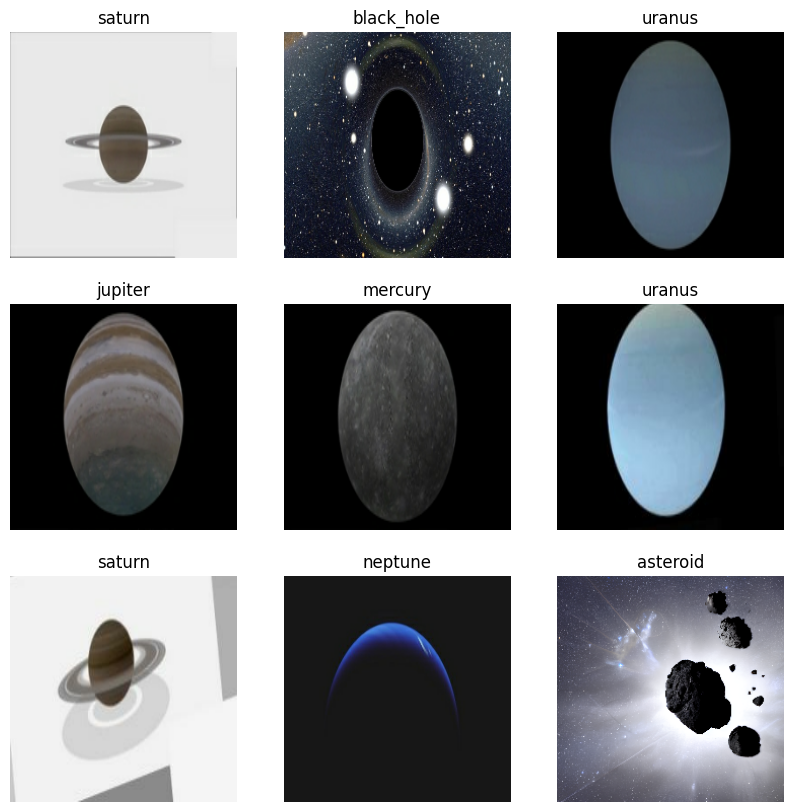

In [4]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [7]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,711 (16.73 MB)

 Trainable params: 333,580 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
callbacks = [

    keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        patience=3,
        factor=0.3
    ),

    keras.callbacks.ModelCheckpoint(
        "astro_model_best.h5",
        save_best_only=True
    )
]

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.2266 - loss: 2.8478

76/76 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.4040 - loss: 2.0570 - val_accuracy: 0.8222 - val_loss: 1.2684 - learning_rate: 1.0000e-04
Epoch 2/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.7628 - loss: 0.8183

76/76 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7860 - loss: 0.7254 - val_accuracy: 0.9362 - val_loss: 0.5894 - learning_rate: 1.0000e-04
Epoch 3/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.8556 - loss: 0.4917

76/76 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8638 - loss: 0.4637 - val_accuracy: 0.9574 - val_loss: 0.3002 - learning_rate: 1.0000e-04
Epoch 4/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9053 - loss: 0.3532

76/76 ━━━━━━━━━━━━━━━━━━━━ 76s 994ms/step - accuracy: 0.9118 - loss: 0.3335 - val_accuracy: 0.9650 - val_loss: 0.1843 - learning_rate: 1.0000e-04
Epoch 5/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.9136 - loss: 0.2993

...

76/76 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9789 - loss: 0.0652 - val_accuracy: 0.9894 - val_loss: 0.0423 - learning_rate: 1.0000e-04
Epoch 21/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.9779 - loss: 0.0684

76/76 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9760 - loss: 0.0721 - val_accuracy: 0.9878 - val_loss: 0.0398 - learning_rate: 1.0000e-04
Epoch 22/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.9839 - loss: 0.0538

76/76 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9830 - loss: 0.0599 - val_accuracy: 0.9909 - val_loss: 0.0382 - learning_rate: 1.0000e-04
Epoch 23/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.9823 - loss: 0.0592

76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9810 - loss: 0.0623 - val_accuracy: 0.9909 - val_loss: 0.0368 - learning_rate: 1.0000e-04
Epoch 24/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9818 - loss: 0.0586 - val_accuracy: 0.9909 - val_loss: 0.0372 - learning_rate: 1.0000e-04
Epoch 25/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.9900 - loss: 0.0425

76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9888 - loss: 0.0469 - val_accuracy: 0.9924 - val_loss: 0.0352 - learning_rate: 1.0000e-04


In [11]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9288 - loss: 0.2359 - val_accuracy: 0.9909 - val_loss: 0.0366
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9404 - loss: 0.1857 - val_accuracy: 0.9878 - val_loss: 0.0470
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9466 - loss: 0.1754 - val_accuracy: 0.9848 - val_loss: 0.0543
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9532 - loss: 0.1496 - val_accuracy: 0.9863 - val_loss: 0.0575
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9565 - loss: 0.1414 - val_accuracy: 0.9878 - val_loss: 0.0581
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9578 - loss: 0.1373 - val_accuracy: 0.9878 - val_loss: 0.0576
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9665 - loss: 0.1205 - val_accuracy: 0.9878 - val_loss: 0.0567
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9648 - loss: 0.1109 - val_accuracy: 0.9894 - val_loss

In [12]:
#Evaluate Model
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 664ms/step - accuracy: 0.9913 - loss: 0.0588
Test Accuracy: 0.991304337978363


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


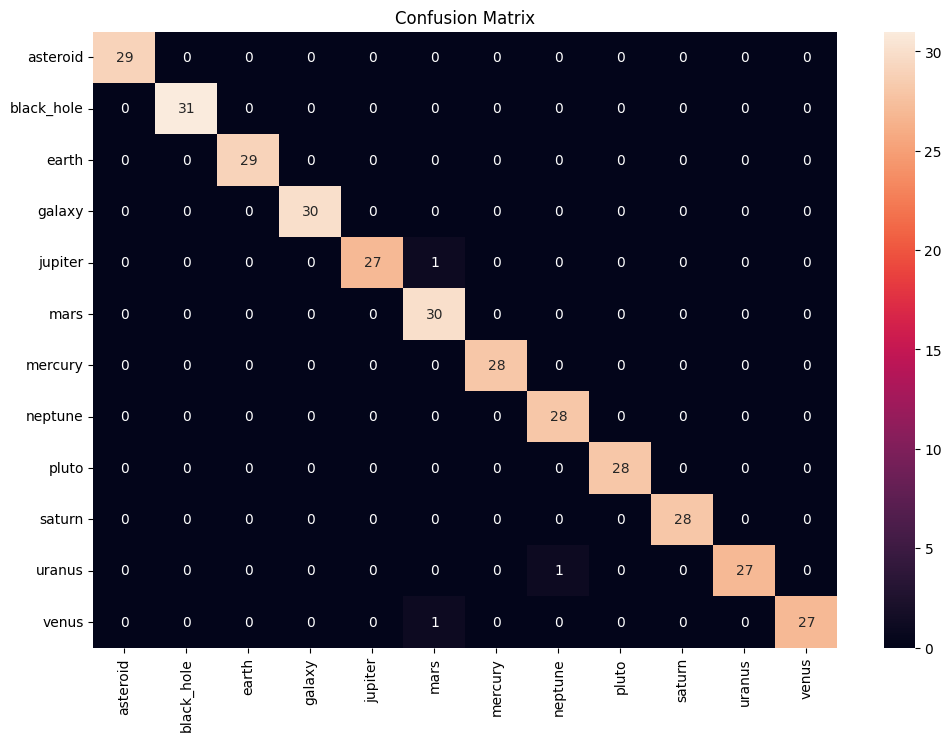

In [13]:
#Confusion Matrix
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(images)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(preds, axis=1)
    )

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.show()

In [14]:
#Classification Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    asteroid       1.00      1.00      1.00        29
  black_hole       1.00      1.00      1.00        31
       earth       1.00      1.00      1.00        29
      galaxy       1.00      1.00      1.00        30
     jupiter       1.00      0.96      0.98        28
        mars       0.94      1.00      0.97        30
     mercury       1.00      1.00      1.00        28
     neptune       0.97      1.00      0.98        28
       pluto       1.00      1.00      1.00        28
      saturn       1.00      1.00      1.00        28
      uranus       1.00      0.96      0.98        28
       venus       1.00      0.96      0.98        28

    accuracy                           0.99       345
   macro avg       0.99      0.99      0.99       345
weighted avg       0.99      0.99      0.99       345



In [15]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    asteroid       1.00      1.00      1.00        29
  black_hole       1.00      1.00      1.00        31
       earth       1.00      1.00      1.00        29
      galaxy       1.00      1.00      1.00        30
     jupiter       1.00      0.96      0.98        28
        mars       0.94      1.00      0.97        30
     mercury       1.00      1.00      1.00        28
     neptune       0.97      1.00      0.98        28
       pluto       1.00      1.00      1.00        28
      saturn       1.00      1.00      1.00        28
      uranus       1.00      0.96      0.98        28
       venus       1.00      0.96      0.98        28

    accuracy                           0.99       345
   macro avg       0.99      0.99      0.99       345
weighted avg       0.99      0.99      0.99       345

